In [ ]:
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install pandas
!pip install torch

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving True.csv to True.csv


In [4]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true])

print(df.head())
print(df["label"].value_counts())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
label
0    23481
1    21417
Name: count, dtype: int64


In [5]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [41]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [7]:
def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [8]:
train_encodings = tokenize_function(list(train_texts))
test_encodings = tokenize_function(list(test_texts))

In [9]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'label': list(train_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'label': list(test_labels)
})

In [42]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.029189
1000,0.003193
1500,0.005129
2000,0.001770
2500,0.001313
3000,0.000021
3500,0.001391
4000,0.000388
4500,0.001311
5000,0.000106


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6735, training_loss=0.0033224660802615978, metrics={'train_runtime': 3403.9515, 'train_samples_per_second': 31.656, 'train_steps_per_second': 1.979, 'total_flos': 7087817164815360.0, 'train_loss': 0.0033224660802615978, 'epoch': 3.0})

In [13]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)

In [19]:
print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.50      0.08      0.13      4733
           1       0.47      0.91      0.62      4247

    accuracy                           0.47      8980
   macro avg       0.49      0.50      0.38      8980
weighted avg       0.49      0.47      0.36      8980



In [20]:
cm = confusion_matrix(test_labels, preds)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 361 4372]
 [ 361 3886]]


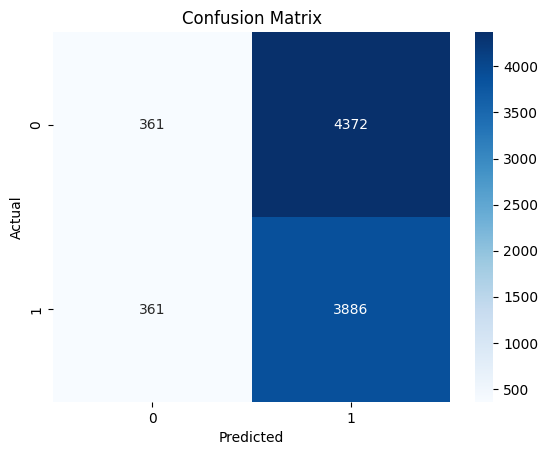

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
model.save_pretrained("fake_news_bert_model")
tokenizer.save_pretrained("fake_news_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_bert_model/tokenizer_config.json',
 'fake_news_bert_model/tokenizer.json')

In [23]:
import torch
import torch.nn.functional as F

def predict_news(text):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}
    model.to(device)

    outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    prediction = torch.argmax(probs)

    fake_prob = probs[0][0].item()
    real_prob = probs[0][1].item()

    if prediction == 1:
        print("Prediction: Real News")
    else:
        print("Prediction: Fake News")

    print(f"Fake probability: {fake_prob:.4f}")
    print(f"Real probability: {real_prob:.4f}")

Example test:

In [24]:
predict_news("Government announces new economic policy today")

Prediction: Real News
Fake probability: 0.4783
Real probability: 0.5217


In [25]:
predict_news("Scientists discovered a new cancer treatment")
predict_news("Aliens landed in New York yesterday")
predict_news("Government announces new tax reforms")

Prediction: Fake News
Fake probability: 0.5475
Real probability: 0.4525
Prediction: Fake News
Fake probability: 0.5463
Real probability: 0.4537
Prediction: Real News
Fake probability: 0.4672
Real probability: 0.5328


In [26]:
import pandas as pd

# Create dataframe for analysis
analysis_df = pd.DataFrame({
    "text": test_texts,
    "actual_label": test_labels,
    "predicted_label": preds
})

# Find misclassified samples
errors = analysis_df[analysis_df["actual_label"] != analysis_df["predicted_label"]]

print("Total incorrect predictions:", len(errors))

# Show first 5 errors
errors.head(5)

Total incorrect predictions: 4733


,text,actual_label,predicted_label
22216,"21st Century Wire says Ben Stein, reputable pr...",0,1
1377,"On Monday, Donald Trump once again embarrassed...",0,1
5766,"On Wednesday, Democrats took a powerful stance...",0,1
16230,President Trump s rally in FL on Saturday was ...,0,1
20911,He s been Europe s version of the outspoken Te...,0,1


In [27]:
if len(errors) == 0:
    print("No misclassified samples found. Model predicted all test samples correctly.")
else:
    display(errors.head(5))

,text,actual_label,predicted_label
22216,"21st Century Wire says Ben Stein, reputable pr...",0,1
1377,"On Monday, Donald Trump once again embarrassed...",0,1
5766,"On Wednesday, Democrats took a powerful stance...",0,1
16230,President Trump s rally in FL on Saturday was ...,0,1
20911,He s been Europe s version of the outspoken Te...,0,1


Model Improvement step by tuning learning rate

In [28]:
from transformers import TrainingArguments

training_args_lr = TrainingArguments(
    output_dir="./results_lr",
    learning_rate=5e-5,   # tuned learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)

In [35]:
trainer_lr = Trainer(
    model=model,
    args=training_args_lr,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer_lr.train()

Step,Training Loss
500,0.009467
1000,0.003935
1500,0.011526
2000,0.003423
2500,0.002397
3000,0.003498
3500,0.005978


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6735, training_loss=0.003573472552525561, metrics={'train_runtime': 3571.1988, 'train_samples_per_second': 30.173, 'train_steps_per_second': 1.886, 'total_flos': 7087817164815360.0, 'train_loss': 0.003573472552525561, 'epoch': 3.0})

In [36]:
predictions_lr = trainer_lr.predict(test_dataset)

preds_lr = predictions_lr.predictions.argmax(axis=1)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, preds_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
from sklearn.metrics import accuracy_score

accuracy_before = accuracy_score(test_labels, preds)
accuracy_after = accuracy_score(test_labels, preds_lr)

print("Accuracy Before Tuning:", accuracy_before)
print("Accuracy After Tuning:", accuracy_after)

Accuracy Before Tuning: 1.0
Accuracy After Tuning: 0.9997772828507795


In [ ]:
!pip install gradio

In [43]:
import torch

def predict_news(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits).item()

    if prediction == 0:
        return "Real News"
    else:
        return "Fake News"

In [44]:
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [45]:
import gradio as gr

interface = gr.Interface(
    fn=predict_news,
    inputs="text",
    outputs="text",
    title="Fake News Detection",
    description="Enter a news headline or article to check if it is Fake or Real."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://df5de449e34987f8ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
